(dl/05-training)=
# Activations and Gradients

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=brightgreen)
[![Source](https://img.shields.io/static/v1.svg?label=GitHub&message=Source&color=181717&logo=GitHub)](https://github.com/particle1331/ok-transformer/blob/master/docs/nb/dl/05-training.ipynb)
[![Stars](https://img.shields.io/github/stars/particle1331/ok-transformer?style=social)](https://github.com/particle1331/ok-transformer)

---

**Readings:**  {cite}`layernorm` {cite}`batchnorm`

## Introduction

Training neural networks involves computation across millions of weights and activations. This process is [known to be fragile](https://lossfunctions.tumblr.com/). In this notebook, we attach hooks to deep neural nets to analyze the statistics of activations, weights and gradients, and consider pitfalls when they are improperly scaled. Finally, we introduce **layer normalization** (LN) {cite}`layernorm` which make training deep networks so much easier. 

In particular, we find that using normalization layers prevent rank collapse of activations and controls the magnitude of gradients. This was shown for networks with increasing depth and trained with increasing learning rates. We also consider the effects of the choice of **activation function**. We find that activations such as GELU {cite}`gelu` and Mish {cite}`mish` have unique effects that are similar to LN on unnormalized networks.

## Preliminaries

In [1]:
import math
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib_inline import backend_inline

DATASET_DIR = Path("./data").absolute()
RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

warnings.simplefilter(action="ignore")
backend_inline.set_matplotlib_formats("png")

Still using the names dataset from the [previous notebook](dl/04-lm):

In [2]:
!wget -O ./data/surnames_freq_ge_100.csv https://raw.githubusercontent.com/jvalhondo/spanish-names-surnames/fdce099ecb22d3b10da76448e1a7787048f12f26/surnames_freq_ge_100.csv
!wget -O ./data/surnames_freq_ge_20_le_99.csv https://raw.githubusercontent.com/jvalhondo/spanish-names-surnames/fdce099ecb22d3b10da76448e1a7787048f12f26/surnames_freq_ge_20_le_99.csv
col = ["surname", "frequency_first", "frequency_second", "frequency_both"]
df1 = pd.read_csv(DATASET_DIR / "surnames_freq_ge_100.csv", names=col, header=0)
df2 = pd.read_csv(DATASET_DIR / "surnames_freq_ge_20_le_99.csv", names=col, header=0)

--2024-03-20 20:30:27--  https://raw.githubusercontent.com/jvalhondo/spanish-names-surnames/fdce099ecb22d3b10da76448e1a7787048f12f26/surnames_freq_ge_100.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.


HTTP request sent, awaiting response... 200 OK
Length: 485781 (474K) [text/plain]
Saving to: ‘./data/surnames_freq_ge_100.csv’

./data/surnames_fre 100%[===================>] 474.40K  --.-KB/s    in 0.1s    

2024-03-20 20:30:28 (3.63 MB/s) - ‘./data/surnames_freq_ge_100.csv’ saved [485781/485781]

--2024-03-20 20:30:28--  https://raw.githubusercontent.com/jvalhondo/spanish-names-surnames/fdce099ecb22d3b10da76448e1a7787048f12f26/surnames_freq_ge_20_le_99.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 848727 (829K) [text/plain]
Saving to: ‘./data/surnames_freq_ge_20_le_99.csv’

./data/surnames_fre 100%[===================>] 828.83K  1.43MB/s    in 0.6s    

2024-03-20 20:30:29 (1.43 MB/s) - ‘./data/surnames_freq_ge_20_le_99.csv’ saved [848727/848727]



In [3]:
FRAC_LIMIT = 0.30
df = pd.concat([df1, df2], axis=0)[['surname']].sample(frac=FRAC_LIMIT)
df['surname'] = df['surname'].map(lambda s: s.lower())
df['surname'] = df['surname'].map(lambda s: s.replace("de la", "dela"))
df['surname'] = df['surname'].map(lambda s: s.replace(" ", "_"))

names = [n for n in df.surname.tolist() if "'" not in n and 'ç' not in n and len(n) >= 2]
df = df[['surname']].dropna().astype(str)
df = df[df.surname.isin(names)]
df.to_csv(DATASET_DIR / 'spanish_surnames.csv', index=False)
df = pd.read_csv(DATASET_DIR / 'spanish_surnames.csv').dropna()
df.head()

,surname
0,gayola
1,sanchez_pobre
2,cuadal
3,bonifacio
4,quiles


### Datasets

Defining here the dataset class used in the [previous notebook](dl/04-lm):

In [4]:
import torch
from torch.utils.data import Dataset

class CharDataset(Dataset):
    def __init__(self, contexts: list[str], targets: list[str], chars: str):
        self.chars = chars
        self.ys = targets
        self.xs = contexts
        self.block_size = len(contexts[0])
        self.itos = {i: c for i, c in enumerate(self.chars)}
        self.stoi = {c: i for i, c in self.itos.items()}

    def get_vocab_size(self):
        return len(self.chars)
    
    def __len__(self):
        return len(self.xs)
    
    def __getitem__(self, idx):
        x = self.encode(self.xs[idx])
        y = torch.tensor(self.stoi[self.ys[idx]]).long()
        return x, y 
        
    def decode(self, x: torch.tensor) -> str:
        return "".join([self.itos[c.item()] for c in x])

    def encode(self, word: str) -> torch.tensor:
        return torch.tensor([self.stoi[c] for c in word]).long()


def build_dataset(names, block_size=3):
    """Build word context -> next char target lists from names."""
    xs = []     # context list
    ys = []     # target list
    for name in names:
        context = ["."] * block_size
        for c in name + ".":
            xs.append(context)
            ys.append(c)
            context = context[1:] + [c]
    
    chars = sorted(list(set("".join(ys))))
    return CharDataset(contexts=xs, targets=ys, chars=chars)

Example dataset with block size 3:

In [5]:
dataset = build_dataset(names, block_size=3)
xs = []
ys = []
for i in range(7):
    x, y = dataset[i]
    xs.append(x)
    ys.append(y)

pd.DataFrame({'x': [x.tolist() for x in xs], 'y': [y.item() for y in ys], 'x_word': ["".join(dataset.decode(x)) for x in xs], 'y_char': [dataset.itos[c.item()] for c in ys]})

,x,y,x_word,y_char
0,"[0, 0, 0]",8,...,g
1,"[0, 0, 8]",2,..g,a
2,"[0, 8, 2]",26,.ga,y
3,"[8, 2, 26]",16,gay,o
4,"[2, 26, 16]",13,ayo,l
5,"[26, 16, 13]",2,yol,a
6,"[16, 13, 2]",0,ola,.


Ideally, we should use a stratified *k*-fold that ensures character distribution is the same between slips. But too lazy. Here we just partition the names dataset by index to create the validation and train datasets.

In [6]:
SPLIT_RATIO = 0.80
split_point = int(SPLIT_RATIO * len(names))
names_train = names[:split_point]
names_valid = names[split_point:]
dataset_train = build_dataset(names_train, block_size=3)
dataset_valid = build_dataset(names_valid, block_size=3)

len(dataset_train), len(dataset_valid)

(149066, 37242)

## Weight initialization

SGD requires choosing an arbitrary starting point $\boldsymbol{\Theta}_{\text{init}}.$ Setting all weights to zero or some constant does not work as symmetry in the neurons of the network will make it difficult (if not impossible) to train the model. Hence, setting the weights randomly to break symmetry is a good starting point. However, this is still not enough since the variance of every neuron [adds up](https://www.deeplearning.ai/ai-notes/initialization/index.html#IV)  (again due to symmetry):

In [7]:
import seaborn as sns

x = torch.randn(1000, 100)
w = torch.randn( 100, 200)
y = x @ w

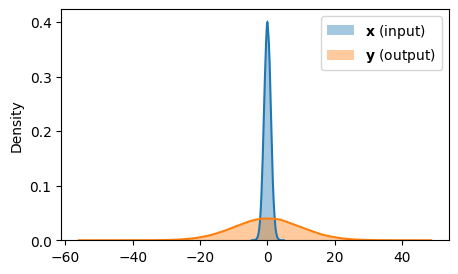

In [8]:
plt.figure(figsize=(5, 3))
sns.distplot(x.reshape(-1), color="C0", label='$\mathbf{x}$ (input)');
sns.distplot(y.reshape(-1), color="C1", label='$\mathbf{y}$ (output)');
plt.legend();

Observe that the output $\boldsymbol{\mathsf{y}} = \boldsymbol{\mathsf{x}}^\top \boldsymbol{\mathsf{w}}$ for normally distributed $\boldsymbol{\mathsf{x}}$ and $\boldsymbol{\mathsf{w}}$ starts to spread out. This makes sense since we are adding $n$ terms where $n$ is the width of the layer. Ideally, we want $\boldsymbol{\mathsf{y}}$ to have unit standard deviation to maintain stable activation flow. Otherwise, activations will recursively grow at each layer. 

Note that activations have regions where their gradients **saturate**, so it is very important to control the range of activations.
This becomes increasingly problematic with depth. 

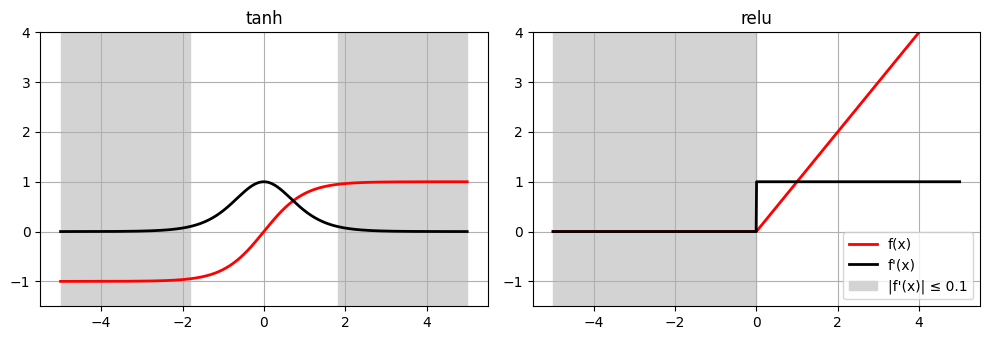

In [9]:
activations = {
    "tanh": torch.tanh,
    "relu": torch.relu,
}

def d(f, x):
    """Compute derivative of activation with respect to x."""
    y = f(x)
    y.backward(torch.ones_like(x))
    return x.grad

def plot_activation(act: str, ax, x):
    x.grad = None
    f = activations[act]
    y = f(x)
    df = d(f, x)
    x, y = x.detach().numpy(), y.detach().numpy()
    
    # Plotting
    ax.plot(x, y,  linewidth=2, color='red',   label="f(x)")
    ax.plot(x, df, linewidth=2, color='black', label="f'(x)")
    ax.set_title(act)
    ax.grid()
    ax.set_ylim(-1.5, 4)
    if act == "tanh":
        ax.axvspan(-5, -1.8183, -10, 10, color='lightgray')
        ax.axvspan(1.8183, 5,   -10, 10, color='lightgray')
    elif act == "relu":
        ax.axvspan(-5, 0, -10, 10, color='lightgray', label="|f'(x)| ≤ 0.1")
        ax.legend(loc='lower right')
    

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

x = torch.linspace(-5, 5, 1000, requires_grad=True)
for i, act_name in enumerate(activations.keys()):
    plot_activation(act_name, ax[i], x)  # divmod(m, n) = m // n, m % n

fig.tight_layout()

**Figure.** Plotting activations and activation gradients. Saturation regions where derivatives are small (here set to `0.1`) are highlighted gray.

<br>

**Xavier init.** {cite}`xavier` Since the variance is additive, one straightforward fix is to initialize the weights $\boldsymbol{\mathsf{w}}$ with a distribution having $\sigma^2=\frac{1}{n}$ where $n$ is the width of the layer {cite}`xavier`. Moreover, we set biases to zero. Note that setting the standard deviation turns out to be equivalent to just scaling the random variable with $\frac{1}{\sqrt{n}}$ by linearity of expectation:

In [10]:
x = torch.randn(1000, 100)
w = torch.randn( 100, 200)
y = x @ (w / np.sqrt(100))

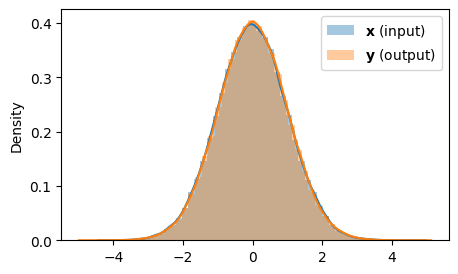

In [11]:
plt.figure(figsize=(5, 3))
sns.distplot(x.reshape(-1), color="C0", label='$\mathbf{x}$ (input)');
sns.distplot(y.reshape(-1), color="C1", label='$\mathbf{y}$ (output)');
plt.legend();

**Remark.** Weight initialization also helps with the variance of gradients. For dense layers, the backprop equations that relate input and output gradients are linear with $\boldsymbol{\mathsf{w}}^\top$, so that we can alternatively scale weights with $1 / \sqrt{n_\text{out}}.$ Indeed, weight init is  [sometimes implemented](https://pytorch.org/docs/stable/nn.init.html#torch.nn.init.xavier_normal_) with the average $\sqrt{2 / {(n_\text{in} + n_\text{out})}}.$

<br>

**Gain.** Note that this scale factor only holds for linear layers. Nonlinear activations **squashes** its input which compounds as we stack layers in deep networks. To counteract this, an easy fix is to introduce a factor called [gain](https://pytorch.org/docs/stable/nn.init.html#torch.nn.init.calculate_gain) on the standard deviation of the weights to compensate for the squashing effect, i.e. $\sigma_{\boldsymbol{\mathsf{w}}} = \mathsf{g} \frac{1}{\sqrt{n}}$ for some $\mathsf{g} > 0.$ Note that $\mathsf{g}$ for an activation is a heuristic that is usually obtained by performing [empirical tests](https://github.com/pytorch/pytorch/issues/24991). 

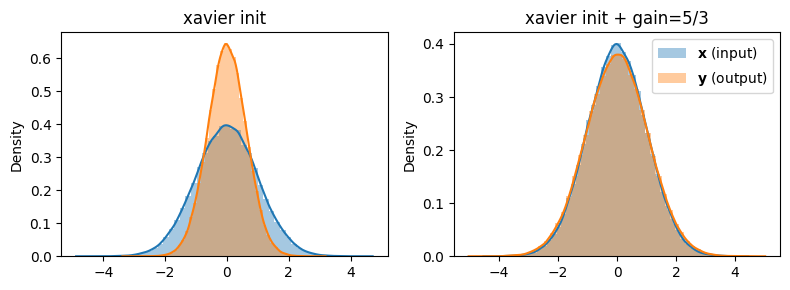

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

n = 100
x = torch.randn(1000, n)
z = torch.tanh(x)   # Note: the input of a hidden layer is an activation
w = torch.randn(n, 200) / n ** 0.5
y = z @ w

sns.distplot(x.reshape(-1), ax=ax[0], color="C0", label='$\mathbf{x}$ (input)');
sns.distplot(y.reshape(-1), ax=ax[0], color="C1", label='$\mathbf{y}$ (output)');
ax[0].set_title("xavier init", size=12)

g = 5 / 3   # tanh gain
x = torch.randn(1000, n)
z = torch.tanh(x)
w = torch.randn(n, 200) * g / n ** 0.5
y = z @ w

sns.distplot(x.reshape(-1), ax=ax[1], color="C0", label='$\mathbf{x}$ (input)');
sns.distplot(y.reshape(-1), ax=ax[1], color="C1", label='$\mathbf{y}$ (output)');

ax[1].set_title("xavier init + gain=5/3", size=12)
ax[1].legend()
fig.tight_layout();

**Remark.** Note that this heuristic also applies to the weights of the logits layer. It essentially acts as **temperature** for the softmax:

In [13]:
import torch.nn.functional as F

x = torch.randn(1, 100)
w = torch.randn(100, 10)
y0 = F.softmax(x @ w)
y1 = F.softmax(x @ (w / np.sqrt(100)))

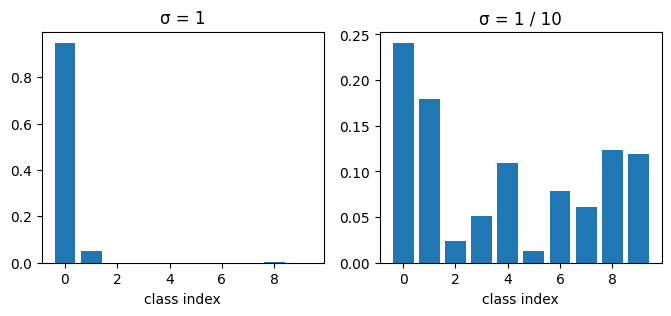

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].set_title("σ = 1")
ax[1].set_title("σ = 1 / 10")
ax[0].set_xlabel("class index")
ax[1].set_xlabel("class index")
ax[0].bar(range(10), y0[0])
ax[1].bar(range(10), y1[0]);

## Training with hooks

The following [previously introduced](dl/03-cnn) class is used to make model training easier. Note that the class is augmented with  **hooks** which we will use to obtain activation and gradient statistics during forward and backward passes. The hooks are attached to the model before training, then removed after.

In [239]:
from tqdm.notebook import tqdm
from contextlib import contextmanager
from torch.utils.data import DataLoader, RandomSampler
import torch.nn as nn

DEVICE = "mps"


@contextmanager
def eval_context(model):
    """Temporarily set to eval mode inside context."""
    state = model.training
    model.eval()
    try:
        yield
    finally:
        model.train(state)


class InfiniteDataLoader:
    def __init__(self, data_loader):
        self.data_loader = data_loader
        self.data_iterator = iter(self.data_loader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            batch = next(self.data_iterator)
        except StopIteration:
            self.data_iterator = iter(self.data_loader)
            batch = next(self.data_iterator)
        return batch


class Trainer:
    def __init__(self,
        model, optim, loss_fn, 
        scheduler=None,
        callbacks=[],
        device=DEVICE, verbose=True
    ):
        self.model = model
        self.optim = optim
        self.device = device
        self.loss_fn = loss_fn
        self.train_log = {'loss': [], 'loss_avg': []}
        self.verbose = verbose
        self.scheduler = scheduler
        self.callbacks = callbacks
        self.forward_hooks = []
        self.backward_hooks = []
    
    def __call__(self, x):
        return self.model(x.to(self.device))

    def forward(self, batch):
        x, y = batch
        x = x.to(self.device)
        y = y.to(self.device)
        return self.model(x), y

    def train_step(self, batch):
        preds, y = self.forward(batch)
        loss = self.loss_fn(preds, y)
        loss.backward()
        self.optim.step()
        self.optim.zero_grad()
        return {'loss': loss}

    @torch.inference_mode()
    def valid_step(self, batch):
        preds, y = self.forward(batch)
        loss = self.loss_fn(preds, y, reduction='sum')
        return {'loss': loss}

    def register_hooks(self,    # !!!
        forward_hooks=[], 
        backward_hooks=[], 
        layer_types=(nn.Linear, nn.Conv2d)
    ):  
        for _, module in self.model.named_modules():
            if isinstance(module, layer_types):
                for f in forward_hooks:
                    h = module.register_forward_hook(f)
                    self.forward_hooks.append(h)
                
                for g in backward_hooks:
                    h = module.register_backward_hook(g)
                    self.backward_hooks.append(h)

    def remove_hooks(self):
        for h in self.forward_hooks + self.backward_hooks:
            h.remove()
    
    def run(self, steps, train_loader):
        train_loader = InfiniteDataLoader(train_loader)
        for _ in tqdm(range(steps)):
            # optim and lr step
            batch = next(train_loader)
            output = self.train_step(batch)
            if self.scheduler:
                self.scheduler.step()

            # step callbacks
            for callback in self.callbacks:
                callback()

            # logs @ train step
            w = int(0.10 * steps)
            self.train_log['loss'].append(output['loss'].item())
            self.train_log['loss_avg'].append(np.mean(self.train_log['loss'][-w:]))

    def evaluate(self, data_loader):
        with eval_context(self.model):
            valid_loss = 0.0
            for batch in data_loader:
                output = self.valid_step(batch)
                valid_loss += output['loss'].item()

        return {'loss': valid_loss / len(data_loader.dataset)}

    @torch.inference_mode()
    def predict(self, x: torch.Tensor):
        with eval_context(self.model):
            return self(x)

    @torch.inference_mode()
    def batch_predict(self, input_loader: DataLoader):
        with eval_context(self.model):
            preds = [self(x) for x in input_loader]
            preds = torch.cat(preds, dim=0)
        return preds

**Remark.** Note that we modify this to take in total steps per run instead of epochs. 
We define an infinite data loader in case the number of steps exceed one epoch.
We also remove validation during training since we are only currently concerned with training dynamics (not generalization). 

Forward hooks are expected to look like:

```python
hook(module, input, output) -> None or modified output
```

On the other hand, backward hook functions should look like: 

```python
hook(module, grad_in, grad_out) -> None or modified grad_in
```

<br>

Next we define classes for handling outputs of the hooks:

In [240]:
class ActivationStats:
    def __init__(self):
        self.records = {}

    def hook_fn(self, module, input, output):
        self.records[module] = self.records.get(module, [])
        self.records[module].append(output)

class GradientStats:
    def __init__(self):
        self.records = {}

    def hook_fn(self, module, grad_in, grad_out):
        self.records[module] = self.records.get(module, [])
        for t in grad_in:
            if t is not None and t.shape == module.weight.data.shape:
                self.records[module].append(t)

Training a model with hooks:

In [271]:
# Setting up the model
vocab_size = 29
emb_size = 10
block_size = 3
width = 30
model = nn.Sequential(
    nn.Embedding(vocab_size, emb_size), nn.Flatten(),
    nn.Linear(block_size * emb_size, width), nn.ReLU(),
    nn.Linear(width, width), nn.ReLU(),
    nn.Linear(width, vocab_size)
)

# Setting up optimization ingredients
model = model.to(DEVICE)
epochs = 1
loss_fn = F.cross_entropy
optim = torch.optim.SGD(model.parameters(), lr=0.1)
trainer = Trainer(model, optim, loss_fn, device=DEVICE)

# Data loaders
train_loader = DataLoader(dataset_train, batch_size=32, drop_last=True, shuffle=True)
valid_loader = DataLoader(dataset_valid, batch_size=32)

# Finally, training...
try:
    activation_stats = ActivationStats()
    gradient_stats = GradientStats()
    trainer.register_hooks(forward_hooks=[activation_stats.hook_fn], backward_hooks=[gradient_stats.hook_fn])
    trainer.run(steps=1000, train_loader=train_loader)
except Exception as e:
    print(e)
finally:
    trainer.remove_hooks()

  0%|          | 0/1000 [00:00<?, ?it/s]

**Remark.** The exact task and model here is not important. See previous notebook for a discussion.

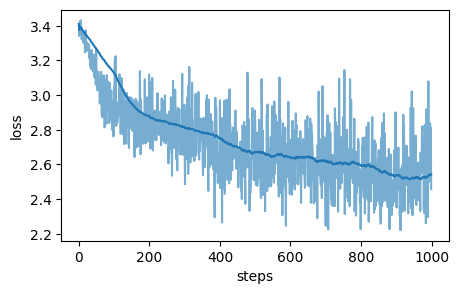

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(trainer.train_log['loss'], alpha=0.6, label='train')
plt.plot(trainer.train_log['loss_avg'], color="C0")
plt.ylabel("loss")
plt.xlabel("steps");

Looking at the activation and gradient statistics during training:

```{margin}
[Colorful dimension](https://forums.fast.ai/t/the-colorful-dimension/42908/5)
```

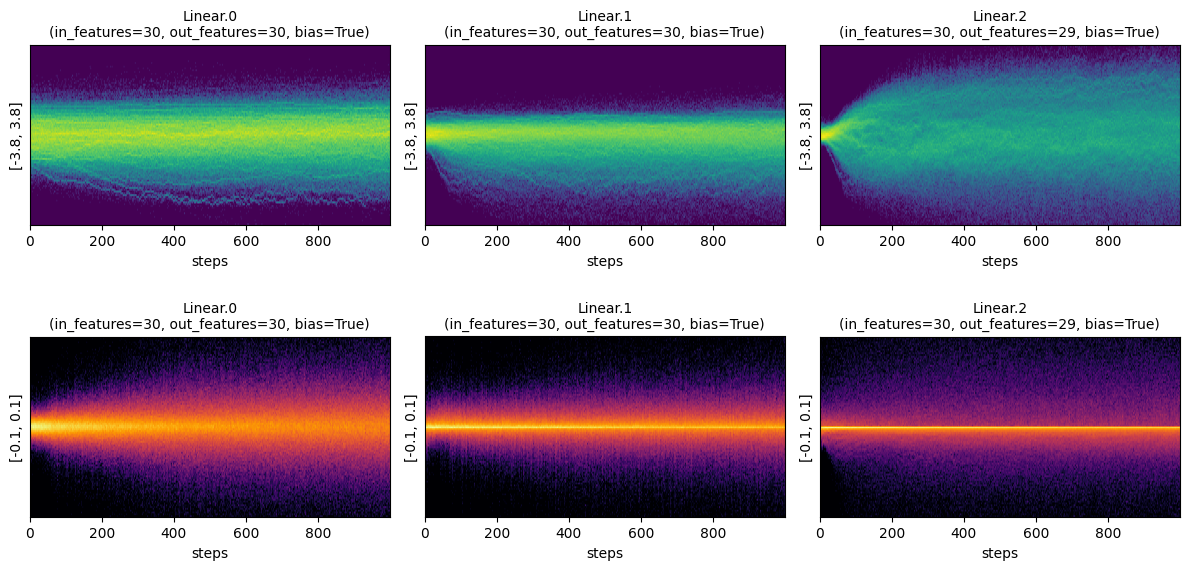

In [ ]:
def plot_training_stats(stats: list, bins: int = 100, num_stds: int = 4, cmaps: list[str] = None, figsize=(6, 2)):
    """Expects hook handlers with .records (dict) having same keys (modules)."""
    
    rows = len(stats)
    cols = len(stats[0].records.keys())
    cmaps = ["viridis"] * rows if cmaps is None else cmaps
    H, W = figsize
    fig, ax = plt.subplots(rows, cols, figsize=(H * rows, W * cols))

    # calculate range per row (i.e. per handler)
    # same range => show vanishing / exploding over layers
    h = {}
    for i in range(rows):
        acts = []
        for j, m in enumerate(stats[0].records.keys()):
            if m not in stats[i].records:
                continue
            acts.append(torch.stack([t.reshape(-1) for t in stats[i].records[m]], dim=0).cpu().reshape(-1))
        h[i] = torch.concat(acts).std().item() * num_stds

    # calculate histograms
    for i in range(rows):
        for j, m in enumerate(stats[0].records.keys()):    
            if m not in stats[i].records:
                continue

            acts = torch.stack([t.reshape(-1) for t in stats[i].records[m]], dim=0).cpu()
            with torch.no_grad():
                # Add one count -> log = more colorful, note: log 1 = 0.
                # total count (i.e. sum per col) == batch_size * num_neurons, .: normalized
                hists = [(torch.histc(acts[j], bins=bins, min=-h[i], max=h[i]) + 1).log().cpu().numpy().reshape(1, -1) for j in range(acts.shape[0])]

            layer, params = str(m).split("(")
            ax[i, j].set_title(layer + "." + str(j) + "\n(" + params, size=10)
            ax[i, j].imshow(np.concatenate(hists, axis=0).T, aspect='auto', cmap=cmaps[i])
            ax[i, j].set_aspect(5)
            ax[i, j].set_yticks([])
            ax[i, j].set_ylabel(f"[{-h[i]:.1f}, {h[i]:.1f}]")
            ax[i, j].set_xlabel("steps")
    
    fig.tight_layout()
    plt.show()

plot_training_stats([activation_stats, gradient_stats], cmaps=["viridis", "inferno"])

**Figure.** First row shows activation histograms over time. Second row are gradients.
Ranges of values are 4$\times\sigma$ from the mean (over all time steps, units, layers).
Considering each layer separately, the network is training somewhat okay (although in the middle layer, [dying ReLUs](https://datascience.stackexchange.com/questions/5706/what-is-the-dying-relu-problem-in-neural-networks) can be concerning). 
Between layers we see that the spread changes.
This can be a problem when we increase depth (e.g. naively adding linear layers).

## Residual connections

## Layer normalization

---

■